# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 09: STRUCTURED MODEL FOR AUDIO HYBRID
# ============================================================
# Purpose:
# This notebook builds the structured modelling branch for the
# same pilot subset used in the audio CNN notebooks.
#
# The goal is to:
# 1. Load the same pilot track list used for audio modelling
# 2. Retrieve the matching engineered audio features
# 3. Train structured models on the same 8-genre task
# 4. Select the best structured model
# 5. Save structured model probabilities for hybrid fusion
# ============================================================

In [22]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Reproducibility
import random

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("Seeds set to:", SEED)

Seeds set to: 42


In [23]:
# ============================================================
# 2. LOAD PILOT METADATA USED FOR AUDIO MODELLING
# ============================================================
# The saved CSV came from a dataframe with flattened MultiIndex
# columns from tracks.csv. It also contains two extra header-like
# rows that need to be removed.

pilot_df = pd.read_csv("../data/processed/audio_large_pilot_metadata.csv")

# Standardize column names
pilot_df.columns = [str(col).strip() for col in pilot_df.columns]

print("Raw pilot metadata shape:", pilot_df.shape)
print("Raw pilot metadata columns:")
print(pilot_df.columns.tolist())

display(pilot_df.head())

# Drop the first two junk rows that came from the original export
pilot_df = pilot_df.iloc[2:].copy()

# Reset index after dropping rows
pilot_df.reset_index(drop=True, inplace=True)

print("Cleaned pilot metadata shape:", pilot_df.shape)
display(pilot_df.head())

Raw pilot metadata shape: (2739, 56)
Raw pilot metadata columns:
['Unnamed: 0', 'album', 'album.1', 'album.2', 'album.3', 'album.4', 'album.5', 'album.6', 'album.7', 'album.8', 'album.9', 'album.10', 'album.11', 'album.12', 'artist', 'artist.1', 'artist.2', 'artist.3', 'artist.4', 'artist.5', 'artist.6', 'artist.7', 'artist.8', 'artist.9', 'artist.10', 'artist.11', 'artist.12', 'artist.13', 'artist.14', 'artist.15', 'artist.16', 'set', 'set.1', 'track', 'track.1', 'track.2', 'track.3', 'track.4', 'track.5', 'track.6', 'track.7', 'track.8', 'track.9', 'track.10', 'track.11', 'track.12', 'track.13', 'track.14', 'track.15', 'track.16', 'track.17', 'track.18', 'track.19', 'audio_path', 'audio_exists', 'encoded_label']


,Unnamed: 0,album,album.1,album.2,album.3,album.4,album.5,album.6,album.7,album.8,...,track.13,track.14,track.15,track.16,track.17,track.18,track.19,audio_path,audio_exists,encoded_label
0,NaN,comments,date_created,date_released,engineer,favorites,id,information,listens,producer,...,license,listens,lyricist,number,publisher,tags,title,NaN,NaN,NaN
1,track_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,171,0,2008-11-26 01:51:52,2009-01-06 00:00:00,NaN,0,74,<p>Unreleased.</p>,346,NaN,...,Attribution-NonCommercial-ShareAlike 3.0 Inter...,242,NaN,2,NaN,[],Marching as Technitions,../data/raw/audio/fma_large\000\000171.mp3,True,7.0
3,178,0,2008-11-26 01:52:07,2009-01-06 00:00:00,NaN,0,76,<p>The first vinyl release from Argumentix.<br...,149,NaN,...,Attribution-NonCommercial-ShareAlike 3.0 Inter...,149,NaN,0,NaN,[],Lend Me a Blanket,../data/raw/audio/fma_large\000\000178.mp3,True,7.0
4,189,0,2008-11-26 01:52:33,2009-01-07 00:00:00,NaN,0,85,<p>Ed originally recorded <em>What I Know </em...,894,NaN,...,Attribution-NonCommercial-ShareAlike 3.0 Inter...,101,NaN,1,NaN,[],The Thought Of It,../data/raw/audio/fma_large\000\000189.mp3,True,3.0


Cleaned pilot metadata shape: (2737, 56)


,Unnamed: 0,album,album.1,album.2,album.3,album.4,album.5,album.6,album.7,album.8,...,track.13,track.14,track.15,track.16,track.17,track.18,track.19,audio_path,audio_exists,encoded_label
0,171,0,2008-11-26 01:51:52,2009-01-06 00:00:00,NaN,0,74,<p>Unreleased.</p>,346,NaN,...,Attribution-NonCommercial-ShareAlike 3.0 Inter...,242,NaN,2,NaN,[],Marching as Technitions,../data/raw/audio/fma_large\000\000171.mp3,True,7.0
1,178,0,2008-11-26 01:52:07,2009-01-06 00:00:00,NaN,0,76,<p>The first vinyl release from Argumentix.<br...,149,NaN,...,Attribution-NonCommercial-ShareAlike 3.0 Inter...,149,NaN,0,NaN,[],Lend Me a Blanket,../data/raw/audio/fma_large\000\000178.mp3,True,7.0
2,189,0,2008-11-26 01:52:33,2009-01-07 00:00:00,NaN,0,85,<p>Ed originally recorded <em>What I Know </em...,894,NaN,...,Attribution-NonCommercial-ShareAlike 3.0 Inter...,101,NaN,1,NaN,[],The Thought Of It,../data/raw/audio/fma_large\000\000189.mp3,True,3.0
3,191,0,2008-11-26 01:52:33,2009-01-07 00:00:00,NaN,0,85,<p>Ed originally recorded <em>What I Know </em...,894,NaN,...,Attribution-NonCommercial-ShareAlike 3.0 Inter...,64,NaN,2,NaN,[],Song About Michael,../data/raw/audio/fma_large\000\000191.mp3,True,3.0
4,205,0,2008-11-26 01:52:33,2009-01-07 00:00:00,NaN,0,85,<p>Ed originally recorded <em>What I Know </em...,894,NaN,...,Attribution-NonCommercial-ShareAlike 3.0 Inter...,69,NaN,9,NaN,[],What Crow Saw,../data/raw/audio/fma_large\000\000205.mp3,True,3.0


In [24]:
# ============================================================
# 3. LOAD PRECOMPUTED ENGINEERED FEATURES
# ============================================================
# features.csv contains the structured audio descriptors used
# for structured modelling.

features = pd.read_csv(
    "../data/raw/metadata/features.csv",
    header=[0, 1, 2],
    index_col=0
)

print("Features shape:", features.shape)

Features shape: (106574, 518)


In [25]:
# ============================================================
# 4. ALIGN FEATURES TO THE SAME PILOT TRACKS
# ============================================================
# Based on inspection of the exported CSV:
# - track ID is in 'Unnamed: 0'
# - split is in 'set'
# - genre_top is in 'track.7'

track_col = "Unnamed: 0"
split_col = "set"
genre_col = "track.7"

# Clean and convert track IDs
pilot_df[track_col] = pd.to_numeric(pilot_df[track_col], errors="coerce")
pilot_df = pilot_df[pilot_df[track_col].notna()].copy()
pilot_df[track_col] = pilot_df[track_col].astype(int)

# Clean useful columns
pilot_df[split_col] = pilot_df[split_col].astype(str).str.strip()
pilot_df[genre_col] = pilot_df[genre_col].astype(str).str.strip()

# Rename to clean standard names for easier downstream use
pilot_df = pilot_df.rename(columns={
    track_col: "track_id",
    split_col: "split",
    genre_col: "genre_top"
})

print("Using track column: track_id")
print("Using split column: split")
print("Using genre column: genre_top")

# Align engineered features to the same tracks
features.index = features.index.astype(int)

pilot_track_ids = pilot_df["track_id"].tolist()
features_pilot = features.loc[pilot_track_ids].copy()

print("Pilot-aligned features shape:", features_pilot.shape)
print("Recovered track IDs:", len(pilot_track_ids))
print("First few recovered track IDs:", pilot_track_ids[:5])

Using track column: track_id
Using split column: split
Using genre column: genre_top
Pilot-aligned features shape: (2737, 518)
Recovered track IDs: 2737
First few recovered track IDs: [171, 178, 189, 191, 205]


In [26]:
# ============================================================
# 5. FLATTEN MULTIINDEX FEATURE COLUMNS
# ============================================================
# The features file uses multi-level column names. We flatten
# them into single strings so they are easier to work with.

features_pilot.columns = [
    "_".join([str(level) for level in col]).strip()
    for col in features_pilot.columns.to_flat_index()
]

print("Flattened feature shape:", features_pilot.shape)
display(features_pilot.head())

Flattened feature shape: (2737, 518)


,chroma_cens_kurtosis_01,chroma_cens_kurtosis_02,chroma_cens_kurtosis_03,chroma_cens_kurtosis_04,chroma_cens_kurtosis_05,chroma_cens_kurtosis_06,chroma_cens_kurtosis_07,chroma_cens_kurtosis_08,chroma_cens_kurtosis_09,chroma_cens_kurtosis_10,...,tonnetz_std_04,tonnetz_std_05,tonnetz_std_06,zcr_kurtosis_01,zcr_max_01,zcr_mean_01,zcr_median_01,zcr_min_01,zcr_skew_01,zcr_std_01
track_id,,,,,,,,,,,,,,,,,,,,,
171,1.314269,0.035812,-0.756844,-1.184000,-0.695854,0.198050,2.545280,2.549930,5.268442,0.705816,...,0.103687,0.019827,0.018808,4.124727,0.420410,0.064992,0.050293,0.0,1.653339,0.057865
178,-0.724701,-0.426607,-0.116223,-0.486726,-0.592573,-0.928542,-0.420204,-0.815510,-0.746821,-0.082805,...,0.087830,0.024371,0.024885,11.484405,0.120605,0.028753,0.027344,0.0,2.153152,0.008448
189,0.348284,-1.012921,-0.422391,-1.054562,-0.578588,-0.339394,-1.208826,-0.367623,-0.055662,-0.606758,...,0.138357,0.045579,0.032305,33.924835,0.403809,0.041273,0.032715,0.0,5.804315,0.050421
191,-0.022110,-1.249446,-0.165796,-0.919464,-0.888402,0.937789,-0.969969,-1.109531,-0.976064,-0.571835,...,0.194829,0.027929,0.028485,75.071182,0.544922,0.049839,0.046875,0.0,8.387897,0.050028
205,-1.294126,-0.882636,-0.670396,-1.157250,-0.933283,-0.340295,-1.156147,-1.135296,-0.845169,-1.014938,...,0.185107,0.030156,0.032795,47.463383,0.566406,0.045558,0.037598,0.0,6.699476,0.061723


In [27]:
# ============================================================
# 6. PREPARE X, y, AND split
# ============================================================

X = features_pilot.copy()
y = pilot_df["genre_top"].astype(str)
split = pilot_df["split"].astype(str)

# Safety cleanup
X = X.select_dtypes(include=["number"])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

print("X shape:", X.shape)
print("y shape:", y.shape)
print("split shape:", split.shape)

print("\nClass distribution:")
print(y.value_counts())

print("\nSplit distribution:")
print(split.value_counts())

X shape: (2737, 518)
y shape: (2737,)
split shape: (2737,)

Class distribution:
genre_top
Rock            350
Folk            350
Experimental    350
Hip-Hop         350
Electronic      350
Pop             350
Instrumental    350
Classical       287
Name: count, dtype: int64

Split distribution:
split
training      2000
test           375
validation     362
Name: count, dtype: int64


In [28]:
# ============================================================
# 7. ENCODE LABELS
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
print(label_encoder.classes_)

Encoded classes:
['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'Pop' 'Rock']


In [29]:
# ============================================================
# 8. CREATE TRAIN / VALIDATION / TEST SETS
# ============================================================

train_mask = (split == "training").values
val_mask = (split == "validation").values
test_mask = (split == "test").values

X_train = X.loc[train_mask].copy()
y_train = y_encoded[train_mask]

X_val = X.loc[val_mask].copy()
y_val = y_encoded[val_mask]

X_test = X.loc[test_mask].copy()
y_test = y_encoded[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2000, 518) (2000,)
Validation: (362, 518) (362,)
Test: (375, 518) (375,)


In [30]:
# ============================================================
# 9. SCALE FEATURES FOR LR AND SVM
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


In [31]:
# ============================================================
# 10. LOGISTIC REGRESSION
# ============================================================

print("\n===== LOGISTIC REGRESSION =====")

lr_model = LogisticRegression(
    max_iter=3000,
    random_state=SEED
)

lr_model.fit(X_train_scaled, y_train)

val_pred_lr = lr_model.predict(X_val_scaled)
val_probs_lr = lr_model.predict_proba(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_lr))

print(classification_report(
    y_val,
    val_pred_lr,
    target_names=label_encoder.classes_,
    zero_division=0
))


===== LOGISTIC REGRESSION =====
Validation Accuracy: 0.4419889502762431
              precision    recall  f1-score   support

   Classical       0.44      0.58      0.50        12
  Electronic       0.35      0.38      0.36        50
Experimental       0.38      0.46      0.41        50
        Folk       0.53      0.50      0.52        50
     Hip-Hop       0.64      0.56      0.60        50
Instrumental       0.36      0.32      0.34        50
         Pop       0.31      0.22      0.26        50
        Rock       0.52      0.62      0.56        50

    accuracy                           0.44       362
   macro avg       0.44      0.46      0.44       362
weighted avg       0.44      0.44      0.44       362



In [32]:
# ============================================================
# 11. RANDOM FOREST
# ============================================================

print("\n===== RANDOM FOREST =====")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

val_pred_rf = rf_model.predict(X_val)
val_probs_rf = rf_model.predict_proba(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_rf))

print(classification_report(
    y_val,
    val_pred_rf,
    target_names=label_encoder.classes_,
    zero_division=0
))


===== RANDOM FOREST =====
Validation Accuracy: 0.5027624309392266
              precision    recall  f1-score   support

   Classical       0.47      0.58      0.52        12
  Electronic       0.45      0.48      0.47        50
Experimental       0.44      0.38      0.41        50
        Folk       0.54      0.74      0.63        50
     Hip-Hop       0.57      0.74      0.64        50
Instrumental       0.38      0.18      0.24        50
         Pop       0.30      0.12      0.17        50
        Rock       0.58      0.86      0.69        50

    accuracy                           0.50       362
   macro avg       0.47      0.51      0.47       362
weighted avg       0.47      0.50      0.47       362



In [33]:
# ============================================================
# 12. SVM
# ============================================================
# We use probability=True because we will later need predicted
# probabilities for hybrid fusion.

print("\n===== SVM =====")

svm_model = SVC(
    C=10,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=SEED
)

svm_model.fit(X_train_scaled, y_train)

val_pred_svm = svm_model.predict(X_val_scaled)
val_probs_svm = svm_model.predict_proba(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_svm))

print(classification_report(
    y_val,
    val_pred_svm,
    target_names=label_encoder.classes_,
    zero_division=0
))


===== SVM =====
Validation Accuracy: 0.4613259668508287
              precision    recall  f1-score   support

   Classical       0.45      0.42      0.43        12
  Electronic       0.35      0.52      0.42        50
Experimental       0.41      0.38      0.40        50
        Folk       0.65      0.72      0.69        50
     Hip-Hop       0.55      0.46      0.50        50
Instrumental       0.39      0.34      0.36        50
         Pop       0.27      0.18      0.22        50
        Rock       0.56      0.64      0.60        50

    accuracy                           0.46       362
   macro avg       0.46      0.46      0.45       362
weighted avg       0.46      0.46      0.45       362



In [34]:
# ============================================================
# 13. MODEL COMPARISON SUMMARY
# ============================================================

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, val_pred_lr),
        accuracy_score(y_val, val_pred_rf),
        accuracy_score(y_val, val_pred_svm)
    ]
})

print("Structured Model Comparison:")
display(model_results)

Structured Model Comparison:


,Model,Validation Accuracy
0,Logistic Regression,0.441989
1,Random Forest,0.502762
2,SVM,0.461326


In [35]:
# ============================================================
# 14. SELECT BEST STRUCTURED MODEL
# ============================================================

validation_scores = {
    "Logistic Regression": accuracy_score(y_val, val_pred_lr),
    "Random Forest": accuracy_score(y_val, val_pred_rf),
    "SVM": accuracy_score(y_val, val_pred_svm)
}

best_model_name = max(validation_scores, key=validation_scores.get)
print("Best structured model:", best_model_name)

Best structured model: Random Forest


In [36]:
# ============================================================
# 15. FINAL TEST EVALUATION FOR BEST MODEL
# ============================================================

if best_model_name == "Logistic Regression":
    best_model = lr_model
    X_test_best = X_test_scaled
    test_pred_best = best_model.predict(X_test_scaled)
    test_probs_best = best_model.predict_proba(X_test_scaled)

elif best_model_name == "Random Forest":
    best_model = rf_model
    X_test_best = X_test
    test_pred_best = best_model.predict(X_test)
    test_probs_best = best_model.predict_proba(X_test)

else:
    best_model = svm_model
    X_test_best = X_test_scaled
    test_pred_best = best_model.predict(X_test_scaled)
    test_probs_best = best_model.predict_proba(X_test_scaled)

structured_test_accuracy = accuracy_score(y_test, test_pred_best)

print("Best Structured Model Test Accuracy:", structured_test_accuracy)

print(classification_report(
    y_test,
    test_pred_best,
    target_names=label_encoder.classes_,
    zero_division=0
))

Best Structured Model Test Accuracy: 0.4053333333333333
              precision    recall  f1-score   support

   Classical       0.62      0.60      0.61        25
  Electronic       0.38      0.42      0.40        50
Experimental       0.37      0.30      0.33        50
        Folk       0.33      0.44      0.38        50
     Hip-Hop       0.64      0.78      0.70        50
Instrumental       0.09      0.06      0.07        50
         Pop       0.18      0.14      0.16        50
        Rock       0.53      0.60      0.56        50

    accuracy                           0.41       375
   macro avg       0.39      0.42      0.40       375
weighted avg       0.38      0.41      0.39       375



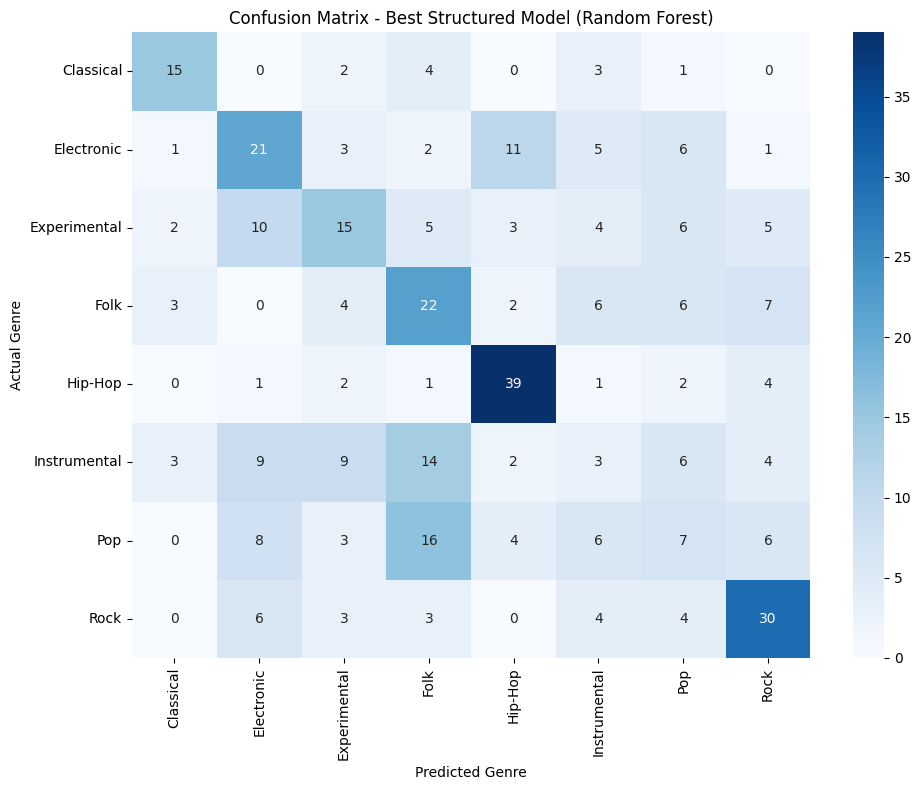

In [37]:
# ============================================================
# 16. CONFUSION MATRIX FOR BEST STRUCTURED MODEL
# ============================================================

cm = confusion_matrix(y_test, test_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title(f"Confusion Matrix - Best Structured Model ({best_model_name})")
plt.tight_layout()
plt.show()

Top 20 Important Features:
spectral_contrast_median_04    0.009654
rmse_std_01                    0.008691
mfcc_max_04                    0.008657
spectral_contrast_mean_04      0.007863
rmse_mean_01                   0.007039
mfcc_std_06                    0.006410
mfcc_max_01                    0.006092
mfcc_mean_01                   0.006055
mfcc_median_04                 0.005953
mfcc_min_01                    0.005655
tonnetz_std_06                 0.005641
rmse_max_01                    0.005575
spectral_contrast_max_07       0.005495
tonnetz_std_05                 0.005470
rmse_median_01                 0.005414
spectral_contrast_median_03    0.005287
mfcc_median_01                 0.005228
tonnetz_std_04                 0.005170
mfcc_median_03                 0.005131
mfcc_max_06                    0.005126
dtype: float64


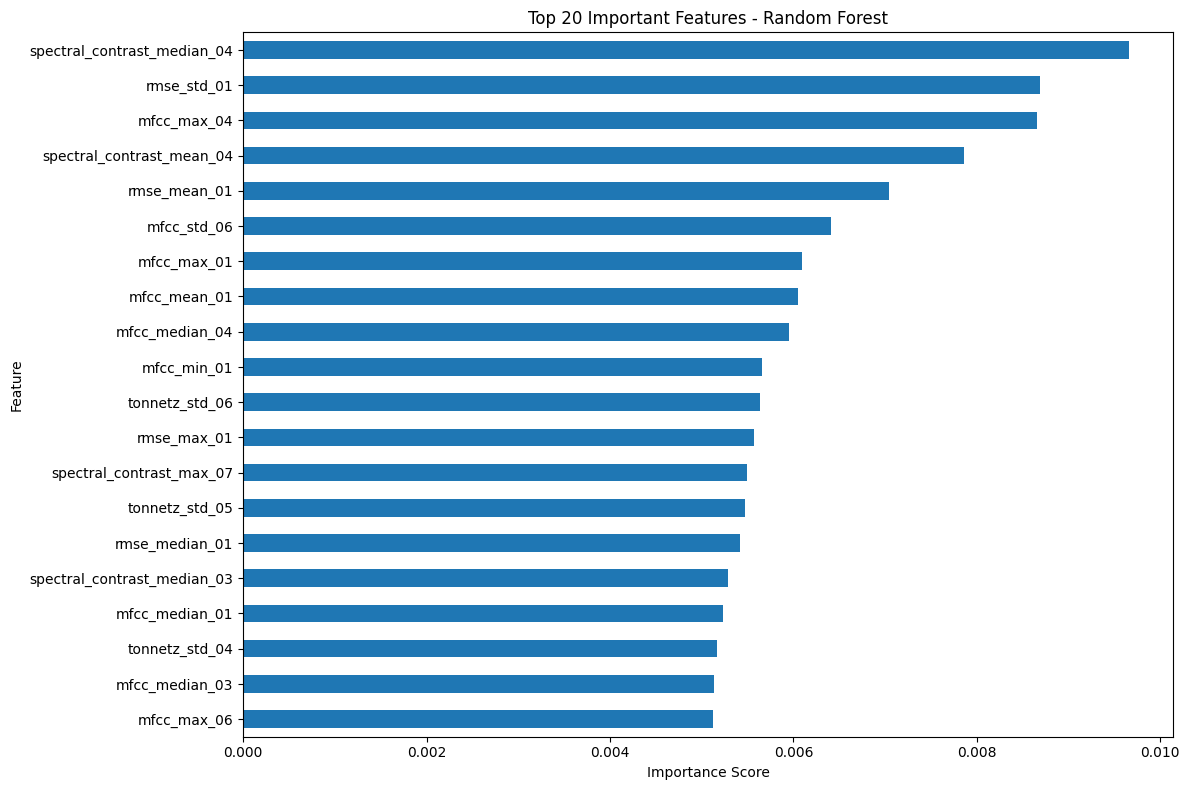

In [38]:
# ============================================================
# 17. FEATURE IMPORTANCE (IF RANDOM FOREST IS BEST)
# ============================================================

if best_model_name == "Random Forest":
    feature_importance = pd.Series(
        rf_model.feature_importances_,
        index=X.columns
    )

    top_features = feature_importance.sort_values(ascending=False).head(20)

    print("Top 20 Important Features:")
    print(top_features)

    plt.figure(figsize=(12, 8))
    top_features.sort_values().plot(kind="barh")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.title("Top 20 Important Features - Random Forest")
    plt.tight_layout()
    plt.show()

In [39]:
# ============================================================
# 18. SAVE STRUCTURED MODEL OUTPUTS FOR HYBRID FUSION
# ============================================================
# We save:
# - validation probabilities
# - test probabilities
# - true labels
# - class names
# - best structured model name
# These will be used in Notebook 10 for fusion with the CNN.

os.makedirs("../data/processed", exist_ok=True)

# Save validation probabilities for all models
np.save("../data/processed/val_probs_lr.npy", val_probs_lr)
np.save("../data/processed/val_probs_rf.npy", val_probs_rf)
np.save("../data/processed/val_probs_svm.npy", val_probs_svm)

# Save best model test probabilities
np.save("../data/processed/structured_test_probs_best.npy", test_probs_best)

# Save labels
np.save("../data/processed/y_val_structured.npy", y_val)
np.save("../data/processed/y_test_structured.npy", y_test)

# Save class names
np.save("../data/processed/structured_label_classes.npy", label_encoder.classes_)

# Save model name and accuracy
with open("../data/processed/best_structured_model_name.txt", "w") as f:
    f.write(best_model_name)

with open("../data/processed/best_structured_model_test_accuracy.txt", "w") as f:
    f.write(str(structured_test_accuracy))

print("Saved structured model outputs for hybrid fusion.")

Saved structured model outputs for hybrid fusion.


In [40]:
# ============================================================
# 19. INTERPRETATION NOTES
# ============================================================

print("1. This notebook trained structured models on the exact same pilot subset used for audio CNN modelling.")
print("2. This ensures that the structured and unstructured branches are directly comparable.")
print("3. The best structured model from this notebook will serve as the structured branch in the final hybrid system.")
print("4. The saved probability outputs will be combined with CNN outputs in the next notebook.")
print("5. The final hybrid system will classify a new audio file by combining engineered audio features and CNN-based spectrogram learning.")

1. This notebook trained structured models on the exact same pilot subset used for audio CNN modelling.
2. This ensures that the structured and unstructured branches are directly comparable.
3. The best structured model from this notebook will serve as the structured branch in the final hybrid system.
4. The saved probability outputs will be combined with CNN outputs in the next notebook.
5. The final hybrid system will classify a new audio file by combining engineered audio features and CNN-based spectrogram learning.


In [41]:
# ============================================================
# SAVE TRAINED STRUCTURED MODEL
# ============================================================

import os
import joblib

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

joblib.dump(best_model, "../models/best_structured_model.joblib")

# Save the exact structured feature column order used in training
np.save("../data/processed/structured_feature_columns.npy", X.columns.to_numpy())

print("Saved best structured model to ../models/best_structured_model.joblib")
print("Saved structured feature column order.")

Saved best structured model to ../models/best_structured_model.joblib
Saved structured feature column order.
